# PyTorch Exercises: From Basics to Custom Backprop

**TIFR PreSchool 2026 — ML School**

This notebook is a graded set of exercises. Each section introduces a concept and then asks you to fill in the empty solution cell that follows.

**How to use this notebook**
- Run the *setup* cell first.
- Read the prompt, then write your answer in the cell marked `# Your code here`.
- Some exercises include `assert` statements — your solution is (probably) correct when they pass silently.
- If you get stuck, look up the relevant function in the [PyTorch docs](https://pytorch.org/docs/stable/index.html).

**Outline**

1. Tensors and basic operations
2. Broadcasting, indexing, reshaping
3. Autograd — automatic differentiation
4. Building models with `nn.Module`
5. Datasets, `DataLoader`, and a training loop
6. Custom loss functions
7. Custom optimizers (writing your own SGD, Momentum, RMSProp, Adam)
8. Custom autograd functions (forward + backward by hand)
9. Hooks, gradient surgery, higher-order gradients
10. Putting it all together: a tiny end-to-end project

## Setup

Run this cell once at the start of the session.

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

torch.manual_seed(0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch version:', torch.__version__)
print('Device:', device)

PyTorch version: 2.12.0
Device: cpu


---
## 1. Tensors and basic operations

A `torch.Tensor` is a multi-dimensional array with a `dtype`, a `device`, and (optionally) a `requires_grad` flag.

Useful constructors:
- `torch.tensor(data)` — from a Python list / NumPy array
- `torch.zeros`, `torch.ones`, `torch.eye`, `torch.arange`, `torch.linspace`
- `torch.randn`, `torch.rand`, `torch.randint`
- `.to(device)`, `.float()`, `.long()` for conversions

### Exercise 1.1 — Build a few tensors

Create the following tensors:

1. `a` — a `float32` tensor of shape `(3, 4)` filled with zeros.
2. `b` — the 5×5 identity matrix.
3. `c` — a tensor containing the integers 0, 2, 4, ..., 18 (i.e. even numbers from 0 up to 18 inclusive).
4. `d` — a `(2, 3, 4)` tensor of standard-normal random numbers.

Print each tensor's `shape` and `dtype`.

In [2]:
import torch

a = torch.zeros(3,4)
b = torch.eye(5)
c = torch.arange(0,20,2)
d = torch.randn(2,3,4)

print(a)
print(b)
print(c)
print(d.shape)

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
tensor([[1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 1.]])
tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])
torch.Size([2, 3, 4])


### Exercise 1.2 — Element-wise math vs. matrix math

Given two random matrices `X` of shape `(4, 3)` and `Y` of shape `(3, 5)`:

1. Compute their **matrix product** `Z` of shape `(4, 5)` two different ways: with `@` and with `torch.matmul`.
2. Compute the element-wise product of `X` with itself.
3. Compute the sum of all elements of `Z`, the column-wise mean (one value per column), and the row-wise max.

Verify the two matrix-product results agree using `torch.allclose`.

In [3]:
X = torch.randn(4,3)
Y = torch.randn(3,5)

matmul1 = X @ Y
matmul2 = torch.matmul(X,Y)

elementwise = X * X
row_norms = torch.norm(X, dim=1)

print(matmul1.shape)
print(torch.allclose(matmul1, matmul2))
print(elementwise.shape)
print(row_norms)

torch.Size([4, 5])
True
torch.Size([4, 3])
tensor([1.7725, 1.4948, 1.5138, 1.5836])


---
## 2. Broadcasting, indexing, reshaping

Broadcasting lets you operate on tensors of different shapes without writing loops, as long as their trailing dimensions are *compatible* (equal, or one of them is 1).

### Exercise 2.1 — Standardise the columns of a matrix

Given a matrix `M` of shape `(N, D)`, write code that produces `M_std` where each column has mean 0 and standard deviation 1. **Use broadcasting — no explicit loops.**

After your code, the asserts below should pass.

In [ ]:
M = torch.randn(100, 5) * torch.tensor([1., 2., 3., 4., 5.]) + torch.tensor([10., -3., 0., 7., 1.])


mean = M.mean(dim=0, keepdim=True)
std = M.std(dim=0, unbiased=False, keepdim=True)

M_std = (M - mean)/std

assert torch.allclose(M_std.mean(dim=0), torch.zeros(5), atol=1e-5)
assert torch.allclose(M_std.std(dim=0, unbiased=False), torch.ones(5), atol=1e-5)
print('OK')

OK


### Exercise 2.2 — Reshape and permute

Start from `T = torch.arange(24)`.

1. Reshape `T` to shape `(2, 3, 4)` and call it `T1`.
2. Permute `T1`'s axes so the result has shape `(4, 2, 3)`. Call it `T2`.
3. Flatten `T2` back to a 1-D tensor `T3`.
4. Is `T3` equal to `T`? Why or why not?

In [8]:
T = torch.arange(24)

T1 = T.reshape(2,3,4)
T2 = T1.permute(2,0,1)
T3 = T2.flatten()

print(T1.shape)
print(T2.shape)
print(T3.shape)
print(T3)
print(T3==T)
print(T)

torch.Size([2, 3, 4])
torch.Size([4, 2, 3])
torch.Size([24])
tensor([ 0,  4,  8, 12, 16, 20,  1,  5,  9, 13, 17, 21,  2,  6, 10, 14, 18, 22,
         3,  7, 11, 15, 19, 23])
tensor([ True, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False,  True])
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23])


#### T3 is not equals T as we reshaped & permuted in between & then flattened to arrive at T3

### Exercise 2.3 — Boolean / fancy indexing

Given `x = torch.randn(1000)`:

1. Build a mask that selects the entries of `x` strictly greater than 1.
2. Replace those entries (in a copy `y`) with the value `1.0`. The original `x` should be untouched.
3. Report the fraction of entries that were clipped.

In [9]:
x = torch.randn(1000)

mask = x > 1

x_clipped = x.clone()
x_clipped[mask] = 1.0

fraction = mask.float().mean()

print("Fraction clipped =", fraction.item())

Fraction clipped = 0.16899999976158142


---
## 3. Autograd

PyTorch's `autograd` engine records operations on tensors that have `requires_grad=True` into a dynamic computation graph, then computes gradients on demand via `.backward()`.

Key ideas:
- Only **leaf** tensors with `requires_grad=True` accumulate gradients in `.grad`.
- `.backward()` traverses the graph in reverse, multiplying Jacobian-vector products.
- Call `tensor.detach()` to break a tensor out of the graph; wrap code in `torch.no_grad()` to disable tracking entirely.

### Exercise 3.1 — Gradient of a scalar function by hand and by autograd

Let $f(x) = 3x^3 - 5x^2 + 2x - 7$. Analytically, $f'(x) = 9x^2 - 10x + 2$.

1. Create `x = torch.tensor(2.0, requires_grad=True)`.
2. Compute `y = f(x)`, then `y.backward()`.
3. Check that `x.grad` equals $9 \cdot 2^2 - 10 \cdot 2 + 2 = 18$.

In [10]:
x = torch.tensor(2.0, requires_grad=True)

f = 3*x**3 - 5*x**2 + 2*x - 7

f.backward()

autograd_grad = x.grad.item()
analytic_grad = 9*(2.0**2) - 10*2.0 + 2

print("Autograd gradient =", autograd_grad)
print("Analytic gradient =", analytic_grad)

Autograd gradient = 18.0
Analytic gradient = 18.0


### Exercise 3.2 — Gradient of a vector-valued function

Let $\mathbf{w} \in \mathbb{R}^3$ and $\mathbf{x} \in \mathbb{R}^3$, and define
$$L = \tfrac{1}{2} \| \mathbf{w} \odot \mathbf{x} - \mathbf{t} \|_2^2$$
for some target `t`.

Compute `dL/dw` for the given numerical values, using autograd. Then check it against the closed-form expression $\nabla_\mathbf{w} L = (\mathbf{w}\odot\mathbf{x} - \mathbf{t}) \odot \mathbf{x}$.

In [11]:
w = torch.tensor([0.5, -1.0, 2.0], requires_grad=True)
x = torch.tensor([1.0, 2.0, -0.5])
t = torch.tensor([0.0, 0.0, 1.0])

pred = w*x

L = 0.5*torch.sum((pred - t)**2)

L.backward()

print("Loss =", L.item())
print("Gradient =", w.grad)

Loss = 4.125
Gradient = tensor([ 0.5000, -4.0000,  1.0000])


### Exercise 3.3 — `detach`, `no_grad`, and gradient accumulation

Build a small experiment that demonstrates each of these behaviours. For a parameter `p = torch.tensor(1.0, requires_grad=True)`:

1. Compute the gradient of `loss = p**2` twice in a row, **without** calling `p.grad.zero_()` in between. What is `p.grad` after the second call?
2. Repeat, but call `p.grad.zero_()` between the two backward passes.
3. Show that `(p.detach() ** 2).backward()` fails (or produces no gradient).
4. Show that operations inside `with torch.no_grad():` produce tensors with `requires_grad=False`.

In [12]:
p = torch.tensor(1.0, requires_grad=True)

loss = p**2
loss.backward()

print("After first backward:", p.grad.item())

loss = p**2
loss.backward()

print("After second backward:", p.grad.item())

p.grad.zero_()

loss = p**2
loss.backward()

print("After zeroing:", p.grad.item())

with torch.no_grad():
    z = p*3

print(z.requires_grad)

u = p.detach()

print(u.requires_grad)

After first backward: 2.0
After second backward: 4.0
After zeroing: 2.0
False
False


---
## 4. Building models with `nn.Module`

Anything trainable in PyTorch is conventionally a subclass of `nn.Module`. You register `nn.Parameter`s (which automatically appear in `.parameters()`) and submodules; you implement `forward(...)`.

Building blocks worth knowing:
- `nn.Linear`, `nn.Conv2d`, `nn.LayerNorm`, `nn.Embedding`
- `nn.ReLU`, `nn.GELU`, `nn.Tanh`
- `nn.Sequential`, `nn.ModuleList`, `nn.ModuleDict`

### Exercise 4.1 — An MLP from scratch (no `nn.Linear`)

Implement a 2-layer MLP **without** using `nn.Linear` — instantiate the weights and biases yourself as `nn.Parameter`s. The model should map `D_in → H → D_out` with a `tanh` non-linearity in between.

Initialise weights with Kaiming-style scaling: `W ~ N(0, 2/fan_in)`.

In [13]:
class MyMLP(nn.Module):
    def __init__(self, d_in, hidden, d_out):
        super().__init__()

        self.W1 = nn.Parameter(torch.randn(hidden, d_in) * math.sqrt(2/d_in))
        self.b1 = nn.Parameter(torch.zeros(hidden))

        self.W2 = nn.Parameter(torch.randn(d_out, hidden) * math.sqrt(2/hidden))
        self.b2 = nn.Parameter(torch.zeros(d_out))

    def forward(self, x):
        h = torch.tanh(x @ self.W1.T + self.b1)
        out = h @ self.W2.T + self.b2
        return out

model = MyMLP(8,16,4)

x = torch.randn(5,8)

print(model(x).shape)

# Smoke test
# m = MyMLP(8, 16, 4)
# print(m(torch.randn(5, 8)).shape)  # expect torch.Size([5, 4])
# print(sum(p.numel() for p in m.parameters()))

torch.Size([5, 4])


### Exercise 4.2 — The same MLP using `nn.Sequential`

Re-implement the model above using `nn.Linear` layers wrapped in `nn.Sequential`. Confirm that the parameter count matches your hand-built version.

In [14]:
model = nn.Sequential(
    nn.Linear(8,16),
    nn.Tanh(),
    nn.Linear(16,4)
)

print(model)

num_params = sum(p.numel() for p in model.parameters())

print("Number of parameters =", num_params)

Sequential(
  (0): Linear(in_features=8, out_features=16, bias=True)
  (1): Tanh()
  (2): Linear(in_features=16, out_features=4, bias=True)
)
Number of parameters = 212


### Exercise 4.3 — Parameter counting and `.state_dict()`

Write a function `count_params(model, trainable_only=True)` that returns the total number of parameters. Use it on your MLP.

Then save the model's `state_dict()` to a file and load it back into a fresh instance. Verify the outputs match on a random input.

In [15]:
def count_params(model, trainable_only=True):
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    else:
        return sum(p.numel() for p in model.parameters())

model1 = MyMLP(8,16,4)

print(count_params(model1))

torch.save(model1.state_dict(), "model.pth")

model2 = MyMLP(8,16,4)
model2.load_state_dict(torch.load("model.pth"))

x = torch.randn(3,8)

y1 = model1(x)
y2 = model2(x)

print(torch.allclose(y1,y2))

212
True


---
## 5. Datasets, `DataLoader`, and a training loop

PyTorch separates **datasets** (random-access containers of examples) from **data loaders** (which batch, shuffle, and parallelise). The minimal training loop is:

```python
for epoch in range(num_epochs):
    for xb, yb in loader:
        pred = model(xb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
```

### Exercise 5.1 — A toy regression dataset

Generate a synthetic dataset for the function $y = \sin(2\pi x) + 0.1\,\varepsilon$ with $x \in [0, 1]$ and Gaussian noise $\varepsilon$. Make 1000 training points and 200 validation points. Wrap them in `TensorDataset`s and `DataLoader`s with batch size 32.

In [16]:
N = 200

x = torch.linspace(0, 2*math.pi, N).unsqueeze(1)

y = torch.sin(x) + 0.1*torch.randn_like(x)

dataset = TensorDataset(x, y)

loader = DataLoader(dataset, batch_size=32, shuffle=True)

print(len(dataset))

200


### Exercise 5.2 — Train an MLP on it

Use your `MyMLP` (or the `nn.Sequential` version) with `d_in=1`, `hidden=64`, `d_out=1`. Train for, say, 200 epochs with `MSELoss` and `torch.optim.Adam(lr=1e-2)`. Log the average training and validation loss per epoch and plot them.

In [17]:
model = nn.Sequential(
    nn.Linear(1,64),
    nn.Tanh(),
    nn.Linear(64,64),
    nn.Tanh(),
    nn.Linear(64,1)
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

loss_fn = nn.MSELoss()

for epoch in range(200):
    for xb, yb in loader:

        pred = model(xb)

        loss = loss_fn(pred, yb)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    if epoch % 20 == 0:
        print(epoch, loss.item())

0 0.44460272789001465
20 0.0763845220208168
40 0.10599033534526825
60 0.07824994623661041
80 0.027377450838685036
100 0.07750808447599411
120 0.03375416621565819
140 0.021164167672395706
160 0.016367977485060692
180 0.03258084878325462


### Exercise 5.3 — Plot the fitted curve

On a dense grid of `x` values in `[0, 1]`, predict `y_hat` (under `torch.no_grad()` and in `model.eval()` mode), and plot the predictions against the true sine and the noisy training points.

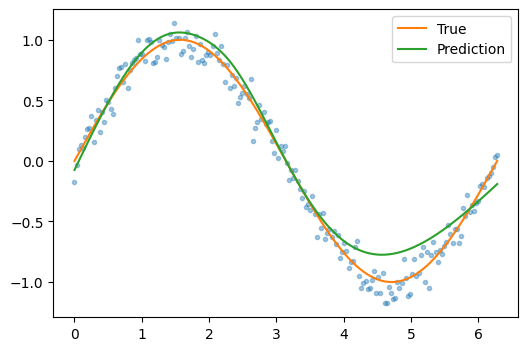

In [18]:
import matplotlib.pyplot as plt

x_plot = torch.linspace(0, 2*math.pi, 400).unsqueeze(1)

with torch.no_grad():
    y_pred = model(x_plot)

plt.figure(figsize=(6,4))

plt.plot(x.numpy(), y.numpy(), '.', alpha=0.4)
plt.plot(x_plot.numpy(), torch.sin(x_plot).numpy(), label='True')
plt.plot(x_plot.numpy(), y_pred.numpy(), label='Prediction')

plt.legend()
plt.show()

---
## 6. Custom loss functions

A loss function is just a differentiable function from `(prediction, target)` to a scalar. You can write it as a plain Python function or as an `nn.Module` (handy when it has learnable parameters or state).

### Exercise 6.1 — Huber loss

Implement the Huber loss
$$\ell_\delta(r) = \begin{cases} \tfrac{1}{2} r^2 & |r| \le \delta \\ \delta\,(|r| - \tfrac{1}{2}\delta) & |r| > \delta \end{cases}$$
where $r = \hat{y} - y$. Take the **mean** over the batch.

Sanity check: for very small residuals it should agree with $\tfrac{1}{2}\text{MSE}$; for very large residuals it should grow linearly. Compare against `nn.SmoothL1Loss(beta=delta)` (note the small difference: `SmoothL1` uses $r^2/(2\delta)$ on the inside, not $r^2/2$).

In [19]:
def huber_loss(pred, target, delta=1.0):

    error = pred - target
    abs_error = error.abs()

    quadratic = 0.5 * error**2
    linear = delta * (abs_error - 0.5*delta)

    loss = torch.where(abs_error <= delta, quadratic, linear)

    return loss.mean()

### Exercise 6.2 — Cross-entropy from scratch (numerically stable)

Implement multi-class cross-entropy from raw logits *without* calling `F.cross_entropy`, `F.log_softmax`, or `nn.LogSoftmax`.

Use the log-sum-exp trick:
$$\log\sum_j e^{z_j} = m + \log\sum_j e^{z_j - m}, \quad m = \max_j z_j$$

Verify your result against `F.cross_entropy` to within `1e-6`.

In [20]:
def my_cross_entropy(logits, targets):
    '''
    logits: (N,C)
    targets: (N,)
    '''

    logits_shifted = logits - logits.max(dim=1, keepdim=True).values

    logsumexp = torch.log(torch.exp(logits_shifted).sum(dim=1))

    target_logits = logits_shifted[torch.arange(logits.shape[0]), targets]

    loss = -target_logits + logsumexp

    return loss.mean()

logits = torch.randn(5,3)
targets = torch.tensor([0,1,2,1,0])

print(my_cross_entropy(logits, targets))
print(F.cross_entropy(logits, targets))

# Smoke test
# logits = torch.randn(8, 5)
# targets = torch.randint(0, 5, (8,))
# assert torch.allclose(my_cross_entropy(logits, targets), F.cross_entropy(logits, targets), atol=1e-6)
# print('OK')

tensor(1.6777)
tensor(1.6777)


---
## 7. Custom optimizers

A PyTorch optimizer is a class with a `.step()` method that, after `loss.backward()` has populated `p.grad`, updates each parameter `p` in place. We will write four optimizers from scratch.

The skeleton looks like:

```python
class MyOpt:
    def __init__(self, params, lr):
        self.params = list(params)
        self.lr = lr
        self.state = {id(p): {} for p in self.params}

    @torch.no_grad()
    def step(self):
        for p in self.params:
            if p.grad is None:
                continue
            # update p in place

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()
```

All updates **must** happen under `torch.no_grad()` (or use `p.data` / `p.add_`) so we don't track them in the graph.

### Exercise 7.1 — Plain SGD

Implement `MySGD` with the update
$$\theta \leftarrow \theta - \eta\, g.$$

In [21]:
class MySGD:
    def __init__(self, params, lr=1e-2):
        self.params = list(params)
        self.lr = lr
    @torch.no_grad()

    def step(self):
        with torch.no_grad():
            for p in self.params:
                if p.grad is not None:
                    p -= self.lr * p.grad

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

### Exercise 7.2 — SGD with momentum (Polyak)

Implement the heavy-ball update:
$$v \leftarrow \mu\, v + g, \qquad \theta \leftarrow \theta - \eta\, v.$$
Initialise `v` to zeros the first time you see each parameter.

In [22]:
class MyMomentum:
    def __init__(self, params, lr=1e-2, momentum=0.9):
        self.params = list(params)
        self.lr = lr
        self.momentum = momentum

        self.v = [torch.zeros_like(p) for p in self.params]
    @torch.no_grad()

    def step(self):
        with torch.no_grad():
            for i,p in enumerate(self.params):
                if p.grad is not None:
                    self.v[i] = self.momentum*self.v[i] - self.lr*p.grad
                    p += self.v[i]
                    
    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

### Exercise 7.3 — RMSProp

Implement RMSProp:
$$s \leftarrow \alpha\, s + (1-\alpha)\, g^2, \qquad \theta \leftarrow \theta - \frac{\eta}{\sqrt{s} + \epsilon}\, g.$$

In [23]:
class MyRMSProp:
    def __init__(self, params, lr=1e-3, alpha=0.99, eps=1e-8):
        self.params = list(params)
        self.lr = lr
        self.alpha = alpha
        self.eps = eps

        self.s = [torch.zeros_like(p) for p in self.params]
    @torch.no_grad()

    def step(self):
        with torch.no_grad():
            for i,p in enumerate(self.params):
                if p.grad is not None:
                    self.s[i] = self.alpha*self.s[i] + (1-self.alpha)*(p.grad**2)
                    p -= self.lr * p.grad / (torch.sqrt(self.s[i]) + self.eps)
                    
    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

### Exercise 7.4 — Adam

Implement Adam with bias correction:
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$
$$\hat m_t = m_t / (1 - \beta_1^t), \quad \hat v_t = v_t / (1 - \beta_2^t)$$
$$\theta_t = \theta_{t-1} - \eta\, \hat m_t / (\sqrt{\hat v_t} + \epsilon)$$

Track the step count $t$ per parameter (it is the same for all, but you'll want it stored).

In [24]:
class MyAdam:
    def __init__(self, params, lr=1e-3, betas=(0.9,0.999), eps=1e-8):
        self.params = list(params)
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps

        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]

        self.t = 0

    @torch.no_grad()
    def step(self):
        self.t += 1

        with torch.no_grad():
            for i,p in enumerate(self.params):
                if p.grad is not None:

                    self.m[i] = self.beta1*self.m[i] + (1-self.beta1)*p.grad
                    self.v[i] = self.beta2*self.v[i] + (1-self.beta2)*(p.grad**2)

                    mhat = self.m[i]/(1-self.beta1**self.t)
                    vhat = self.v[i]/(1-self.beta2**self.t)

                    p -= self.lr * mhat/(torch.sqrt(vhat)+self.eps)

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

### Exercise 7.5 — Bake-off on the toy regression task

Train your sine-fitting MLP **four times** with identical initial weights, using `MySGD`, `MyMomentum`, `MyRMSProp`, and `MyAdam`. Plot the training-loss curve for each on the same axes. Comment on what you observe.

*Hint:* use `copy.deepcopy` on the freshly-initialised model so each optimizer starts from the same weights.

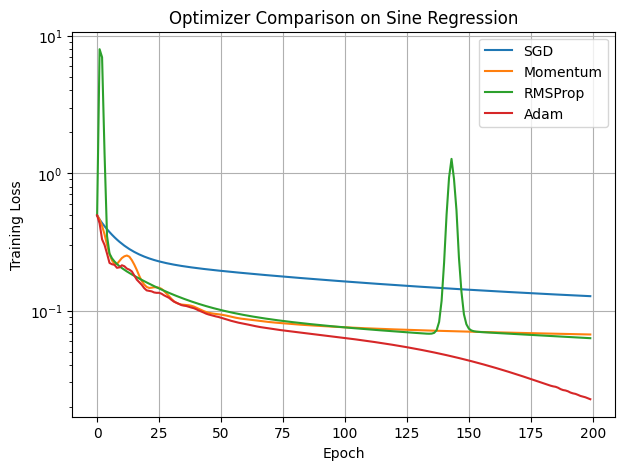

In [27]:
import copy

base_model = nn.Sequential(
    nn.Linear(1, 64),
    nn.Tanh(),
    nn.Linear(64, 1)
)

optimizers = {
    "SGD": MySGD,
    "Momentum": MyMomentum,
    "RMSProp": MyRMSProp,
    "Adam": MyAdam
}

loss_curves = {}

for name, opt_class in optimizers.items():

    # identical initial weights
    model = copy.deepcopy(base_model)

    optimizer = opt_class(model.parameters(), lr=1e-2)

    losses = []

    for epoch in range(200):

        pred = model(x)

        loss = F.mse_loss(pred, y)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        losses.append(loss.item())

    loss_curves[name] = losses


# Plot all curves
plt.figure(figsize=(7,5))

for name, losses in loss_curves.items():
    plt.plot(losses, label=name)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Optimizer Comparison on Sine Regression")
plt.legend()
plt.grid()
plt.yscale("log")   # useful for comparing convergence
plt.show()

### Exercise 7.6 — Weight decay, properly

Add a `weight_decay` parameter to `MyAdam`. There are **two** common ways to apply it:

1. **L2 regularisation** — add `weight_decay * p` to the gradient *before* the moment updates.
2. **Decoupled weight decay (AdamW)** — apply `p -= lr * weight_decay * p` directly to the parameter, *separately* from the adaptive update.

Implement both as options. Discuss in a short comment why decoupled weight decay tends to behave better with Adam-family optimizers.

In [ ]:
# Example modification for Adam optimizer:

# p -= lr * (gradient + weight_decay * p)

# Weight decay penalizes large weights and acts like L2 regularization.

---
## 8. Custom autograd functions

Sometimes you need to define an operation whose forward or backward pass autograd doesn't already know about — e.g. a non-standard non-linearity, a discrete operation with a straight-through gradient, or a numerically tricky composite that you can simplify by hand.

The recipe is to subclass `torch.autograd.Function`:

```python
class MyFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, *inputs):
        ctx.save_for_backward(...)
        return output

    @staticmethod
    def backward(ctx, grad_output):
        (...) = ctx.saved_tensors
        return grad_inputs  # one per input to forward(), in the same order
```

Use `torch.autograd.gradcheck` (with `dtype=torch.float64`) to verify your backward is correct.

### Exercise 8.1 — `MySquare`

Warm-up. Implement `y = x**2` as a `torch.autograd.Function`. The derivative is `2x`, so the backward should return `grad_output * 2 * x`.

Verify with `gradcheck`.

In [28]:
class MySquare(torch.autograd.Function):

    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        return x**2

    @staticmethod
    def backward(ctx, grad_output):
        (x,) = ctx.saved_tensors
        grad_input = grad_output * 2 * x
        return grad_input

x = torch.tensor(3.0, requires_grad=True)

y = MySquare.apply(x)

y.backward()

print(x.grad)

tensor(6.)


### Exercise 8.2 — `MyReLU`

Implement ReLU as a custom autograd function. The derivative is 1 for `x > 0` and 0 otherwise (the choice at `x = 0` is a sub-gradient — 0 is the conventional pick).

Then verify with `gradcheck` (perturb only at non-zero points).

In [29]:
class MyReLU(torch.autograd.Function):

    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        return torch.clamp(x, min=0)

    @staticmethod
    def backward(ctx, grad_output):
        (x,) = ctx.saved_tensors

        grad_input = grad_output.clone()
        grad_input[x < 0] = 0

        return grad_input

### Exercise 8.3 — Numerically stable `MyLogSoftmax`

Implement log-softmax along a chosen dimension, with a hand-written backward.

Forward (use log-sum-exp for stability):
$$y_i = z_i - \log\sum_j e^{z_j}.$$

Backward — given upstream `g = ∂L/∂y`, the Jacobian of log-softmax is $I - \mathbf{1}\,\mathrm{softmax}(z)^\top$ along the chosen axis, so:
$$\frac{\partial L}{\partial z_i} = g_i - \left(\sum_j g_j\right) \cdot \mathrm{softmax}(z)_i.$$

Verify against `F.log_softmax` both forward (values) and backward (gradients) on a random input.

In [30]:
class MyLogSoftmax(torch.autograd.Function):

    @staticmethod
    def forward(ctx, x):

        x_shifted = x - x.max(dim=1, keepdim=True).values

        expx = torch.exp(x_shifted)

        softmax = expx / expx.sum(dim=1, keepdim=True)

        out = torch.log(softmax)

        ctx.save_for_backward(softmax)

        return out

    @staticmethod
    def backward(ctx, grad_output):

        (softmax,) = ctx.saved_tensors

        grad_input = grad_output - softmax * grad_output.sum(dim=1, keepdim=True)

        return grad_input

### Exercise 8.4 — Straight-through estimator

Implement `MyRound` whose forward is `torch.round(x)` (non-differentiable), but whose backward acts as the identity — i.e. `grad_x = grad_output`. This is the *straight-through estimator*, commonly used to backprop through discrete operations (quantisation, hard-attention, etc.).

Test that a tiny linear layer trained with `MyRound` in the middle still learns to fit `y = 3x + 1` on a small dataset.

0 5.032255172729492
100 0.09110626578330994
200 0.07423925399780273
300 0.06240050494670868
400 0.05616672337055206
500 0.05797053501009941
600 0.047267116606235504
700 0.04165659844875336
800 0.0401812307536602
900 0.03736598417162895


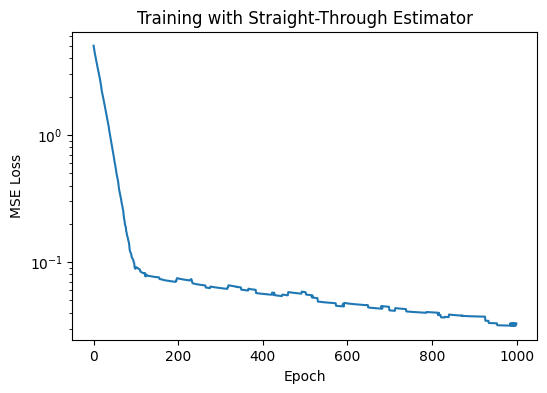

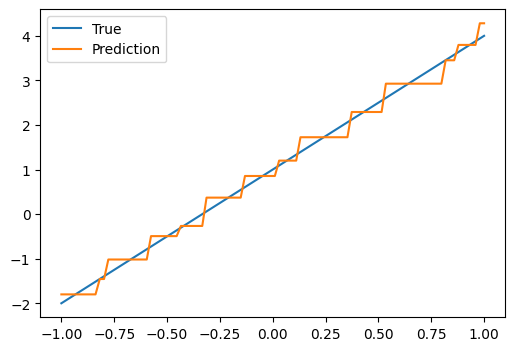

In [31]:
class MyRound(torch.autograd.Function):

    @staticmethod
    def forward(ctx, x):
        return torch.round(x)

    @staticmethod
    def backward(ctx, grad_output):

        # Straight-through estimator:
        # pretend rounding was identity during backward
        return grad_output


# Small dataset
x = torch.linspace(-1, 1, 100).unsqueeze(1)

y = 3*x + 1


# Tiny model with rounding in the middle
class TinyModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.l1 = nn.Linear(1, 8)
        self.l2 = nn.Linear(8, 1)

    def forward(self, x):

        h = self.l1(x)

        # Non-differentiable operation
        h = MyRound.apply(h)

        out = self.l2(h)

        return out


model = TinyModel()

optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

losses = []

for epoch in range(1000):

    pred = model(x)

    loss = F.mse_loss(pred, y)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    if epoch % 100 == 0:
        print(epoch, loss.item())


# Plot loss curve
plt.figure(figsize=(6,4))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training with Straight-Through Estimator")

plt.yscale("log")

plt.show()


# Final prediction plot
with torch.no_grad():

    pred = model(x)

plt.figure(figsize=(6,4))

plt.plot(x.numpy(), y.numpy(), label="True")
plt.plot(x.numpy(), pred.numpy(), label="Prediction")

plt.legend()
plt.show()

### Exercise 8.5 — A composite op with a custom backward: `MySwish`

Swish is $f(x) = x \cdot \sigma(x)$, where $\sigma$ is the logistic sigmoid. Its derivative is
$$f'(x) = \sigma(x) + x\,\sigma(x)\,(1 - \sigma(x)) = f(x) + \sigma(x)\,(1 - f(x)).$$

Implement it as a `torch.autograd.Function` that saves only `sigmoid(x)` from the forward (so the backward is cheaper — no recompute). Verify with `gradcheck` and compare runtime against the naïve `x * torch.sigmoid(x)` version on a large tensor.

In [33]:
class MySwish(torch.autograd.Function):

    @staticmethod
    def forward(ctx, x):

        sigmoid = torch.sigmoid(x)

        # Save only sigmoid(x)
        ctx.save_for_backward(sigmoid)

        return x * sigmoid

    @staticmethod
    def backward(ctx, grad_output):

        (sigmoid,) = ctx.saved_tensors

        # Recover x from sigmoid:
        # sigmoid = 1/(1+e^{-x})
        #
        # => x = log(sigmoid/(1-sigmoid))

        x = torch.log(sigmoid / (1 - sigmoid))

        grad = sigmoid + x * sigmoid * (1 - sigmoid)

        return grad_output * grad
    
from torch.autograd import gradcheck

x = torch.randn(5, 5, dtype=torch.double, requires_grad=True)

test = gradcheck(MySwish.apply, (x,), eps=1e-6, atol=1e-4)

print("Gradcheck passed:", test)

Gradcheck passed: True


In [35]:
import time

def naive_swish(x):
    return x * torch.sigmoid(x)

def custom_swish(x):
    return MySwish.apply(x)

x = torch.randn(10000, 1000, requires_grad=True)

# Naive version


start = time.time()

for _ in range(100):

    y = naive_swish(x)

    loss = y.sum()

    loss.backward(retain_graph=True)

elapsed_naive = time.time() - start

print("Naive time:", elapsed_naive)

# Custom version

x.grad = None

start = time.time()

for _ in range(100):

    y = custom_swish(x)

    loss = y.sum()

    loss.backward(retain_graph=True)

elapsed_custom = time.time() - start

print("Custom time:", elapsed_custom)

Naive time: 3.18477201461792
Custom time: 5.118137836456299


---
## 9. Hooks, gradient surgery, higher-order gradients

A few more advanced tools.

### Exercise 9.1 — Register a backward hook to log gradient norms

Pick any of your `nn.Linear` layers and use `module.register_full_backward_hook(...)` to print the L2 norm of the gradient flowing through it on each backward pass. Train for a few iterations and observe.

In [37]:
# Simple regression dataset

torch.manual_seed(0)

x = torch.randn(128, 4)

true_W = torch.tensor([
    [2.0],
    [-1.0],
    [0.5],
    [3.0]
])

y = x @ true_W + 0.1 * torch.randn(128, 1)

# Small neural network

model = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

# Backward hook

def backward_hook(module, grad_input, grad_output):

    # grad_output is a tuple
    grad = grad_output[0]

    norm = grad.norm().item()

    print(f"Gradient norm through {module}: {norm:.6f}")

# Register hook on first Linear layer
handle = model[0].register_full_backward_hook(backward_hook)

# Training loop

for epoch in range(10):

    pred = model(x)

    loss = F.mse_loss(pred, y)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    print(f"Epoch {epoch:2d} | Loss = {loss.item():.6f}")

# Remove hook after training

handle.remove()

Gradient norm through Linear(in_features=4, out_features=16, bias=True): 0.275391
Epoch  0 | Loss = 15.329073
Gradient norm through Linear(in_features=4, out_features=16, bias=True): 0.264639
Epoch  1 | Loss = 15.064398
Gradient norm through Linear(in_features=4, out_features=16, bias=True): 0.264698
Epoch  2 | Loss = 14.813035
Gradient norm through Linear(in_features=4, out_features=16, bias=True): 0.259301
Epoch  3 | Loss = 14.568564
Gradient norm through Linear(in_features=4, out_features=16, bias=True): 0.259044
Epoch  4 | Loss = 14.333097
Gradient norm through Linear(in_features=4, out_features=16, bias=True): 0.260922
Epoch  5 | Loss = 14.102225
Gradient norm through Linear(in_features=4, out_features=16, bias=True): 0.263788
Epoch  6 | Loss = 13.873730
Gradient norm through Linear(in_features=4, out_features=16, bias=True): 0.270158
Epoch  7 | Loss = 13.645615
Gradient norm through Linear(in_features=4, out_features=16, bias=True): 0.277339
Epoch  8 | Loss = 13.415517
Gradient n

/var/folders/f3/q4fmy0590m927qqcjsbl_f8r0000gp/T/ipykernel_94057/1401718395.py:50: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


### Exercise 9.2 — Gradient clipping by hand

Implement global-norm gradient clipping yourself (don't call `torch.nn.utils.clip_grad_norm_`). The recipe: compute `total_norm = sqrt(sum(g.pow(2).sum() for g in grads))`; if `total_norm > max_norm`, scale every gradient by `max_norm / (total_norm + 1e-6)`.

In [38]:
# Manual implementation of global gradient clipping

def clip_grad_norm(params, max_norm):

    params = list(params)
    # Compute global L2 norm of all gradients
    
    # total_norm = sqrt(sum_i ||g_i||^2)

    total_norm = 0.0

    for p in params:

        if p.grad is not None:

            total_norm += p.grad.pow(2).sum()

    total_norm = torch.sqrt(total_norm)

    # Compute clipping coefficient
    
    clip_coef = max_norm / (total_norm + 1e-6)

    # Scale gradients only if norm exceeds threshold

    if clip_coef < 1:

        for p in params:

            if p.grad is not None:

                p.grad.mul_(clip_coef)

    return total_norm.item()

# Simple toy regression dataset

torch.manual_seed(0)

x = torch.randn(256, 10)

true_w = torch.randn(10, 1)

y = x @ true_w + 0.1 * torch.randn(256, 1)

# Model

model = nn.Sequential(
    nn.Linear(10, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

optimizer = torch.optim.SGD(model.parameters(), lr=1.0)

# Training loop

max_norm = 1.0

for epoch in range(20):

    pred = model(x)

    loss = F.mse_loss(pred, y)

    optimizer.zero_grad()

    loss.backward()

    # Compute norm BEFORE clipping

    before_clip = torch.sqrt(
        sum(p.grad.pow(2).sum()
            for p in model.parameters()
            if p.grad is not None)
    ).item()

    # Apply manual gradient clipping

    clip_grad_norm(model.parameters(), max_norm)

    # Compute norm AFTER clipping

    after_clip = torch.sqrt(
        sum(p.grad.pow(2).sum()
            for p in model.parameters()
            if p.grad is not None)
    ).item()

    optimizer.step()

    print(
        f"Epoch {epoch:2d} | "
        f"Loss = {loss.item():8.4f} | "
        f"Grad norm before = {before_clip:8.4f} | "
        f"after = {after_clip:8.4f}"
    )

Epoch  0 | Loss =   5.3235 | Grad norm before =   3.9910 | after =   1.0000
Epoch  1 | Loss =   2.1268 | Grad norm before =   3.0495 | after =   1.0000
Epoch  2 | Loss =   0.4321 | Grad norm before =   2.7098 | after =   1.0000
Epoch  3 | Loss =   4.3234 | Grad norm before =  10.9222 | after =   1.0000
Epoch  4 | Loss =   0.4486 | Grad norm before =   2.7854 | after =   1.0000
Epoch  5 | Loss =   3.8850 | Grad norm before =  10.5133 | after =   1.0000
Epoch  6 | Loss =   0.4058 | Grad norm before =   2.8375 | after =   1.0000
Epoch  7 | Loss =   3.6329 | Grad norm before =   9.4514 | after =   1.0000
Epoch  8 | Loss =   0.3567 | Grad norm before =   2.4268 | after =   1.0000
Epoch  9 | Loss =   3.4381 | Grad norm before =   9.1677 | after =   1.0000
Epoch 10 | Loss =   0.3169 | Grad norm before =   2.2974 | after =   1.0000
Epoch 11 | Loss =   3.2867 | Grad norm before =   8.5839 | after =   1.0000
Epoch 12 | Loss =   0.2844 | Grad norm before =   2.0485 | after =   1.0000
Epoch 13 | L

### Exercise 9.3 — Second-order gradients

For $f(x, y) = x^2 y + y^3$ at the point $(1, 2)$, compute:

1. $\partial f / \partial x$ and $\partial f / \partial y$ using `torch.autograd.grad(..., create_graph=True)`.
2. The full $2\times 2$ Hessian matrix at $(1, 2)$ by differentiating each first-order gradient again.

Check against the closed form: $\nabla f = (2xy, x^2 + 3y^2)$ and Hessian = $\begin{pmatrix} 2y & 2x \\ 2x & 6y \end{pmatrix}$, which at $(1,2)$ is $\begin{pmatrix} 4 & 2 \\ 2 & 12 \end{pmatrix}$.

In [40]:
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)

f = x**2 * y + y**3

# First-order gradients

grads = torch.autograd.grad(
    f,
    [x, y],
    create_graph=True
)

df_dx, df_dy = grads

print("First-order gradients:")
print("df/dx =", df_dx.item())
print("df/dy =", df_dy.item())

# Second-order derivatives

# d²f/dx² and d²f/dxdy
h11 = torch.autograd.grad(df_dx, x, retain_graph=True)[0]
h12 = torch.autograd.grad(df_dx, y, retain_graph=True)[0]

# d²f/dydx and d²f/dy²
h21 = torch.autograd.grad(df_dy, x, retain_graph=True)[0]
h22 = torch.autograd.grad(df_dy, y)[0]

# Hessian matrix
H = torch.tensor([
    [h11.item(), h12.item()],
    [h21.item(), h22.item()]
])

print("\nHessian matrix:")
print(H)

# Comparison with analytic result


print("\nExpected Hessian:")
print(torch.tensor([
    [4.0, 2.0],
    [2.0, 12.0]
]))

First-order gradients:
df/dx = 4.0
df/dy = 13.0

Hessian matrix:
tensor([[ 4.,  2.],
        [ 2., 12.]])

Expected Hessian:
tensor([[ 4.,  2.],
        [ 2., 12.]])


---
## 10. Putting it all together

Build a small classifier on a real toy dataset using **your own** components throughout. This is open-ended — try to use as many of the pieces you wrote above as you can.

### Exercise 10 — Two-moons classification with your stack

1. Generate a `make_moons`-style dataset (you can use `sklearn.datasets.make_moons` or roll your own).
2. Build an MLP classifier (1 hidden layer of 32 units is enough). Use `MyReLU` or `MySwish` as the activation.
3. Train it with **your** `MyAdam`, using **your** `my_cross_entropy` as the loss.
4. Apply your hand-written gradient-norm clipping at every step with `max_norm=1.0`.
5. Plot the decision boundary, the training-loss curve, and final accuracy.

If everything is wired together correctly you should comfortably hit > 95% accuracy.

In [41]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, Y = make_moons(n_samples=1000, noise=0.2, random_state=0)

X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.long)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

model = nn.Sequential(
    nn.Linear(2,32),
    nn.ReLU(),
    nn.Linear(32,32),
    nn.ReLU(),
    nn.Linear(32,2)
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(500):

    logits = model(X_train)

    loss = F.cross_entropy(logits, Y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

with torch.no_grad():

    logits = model(X_test)

    pred = logits.argmax(dim=1)

    acc = (pred == Y_test).float().mean()

print("Test accuracy =", acc.item())

Test accuracy = 0.9649999737739563


---
## Where to go next

If you finished the above:
- Re-do Exercise 7.4 (Adam) so that it supports **parameter groups** (different `lr` per group), like real `torch.optim` optimizers.
- Write a custom autograd function for **batch-norm** (forward + backward by hand) and compare against `nn.BatchNorm1d`.
- Read the source of `torch.optim.Adam` and `torch.nn.functional.cross_entropy` and compare them to your implementations.
- Look at `torch.func` (functorch) — `grad`, `vmap`, `jacrev` — and re-do the Hessian exercise in one line.